# **Project 1: Concept Bottleneck Models on CelebA (Smiling)**


------------------------------------------------------
Carla Aranda Sánchez - 100523031

Jorge Barcia Belinchón - 100496595

 Marina Juzgado Gómez-Menor - 100523023

 Iván López Anca - 100523112

------------------------------------------------------


## **Introduction: Bottleneck Models**

Deep learning models, particularly Convolutional Neural Networks, are among the best algorithms for complex pattern recognition, in the case of this project, to recognize if the person in the photo is smiling or not based on CelebA dataset. However, using neural networks directly does not allow us to know why the model has taken a decision and what criteria has led it to the final statement, it acts as a "black box". This is why the concept of Bottleneck Model is necessary for this project.

Bottleneck model proposes an architecture where the network is forced to pass through an intermediate layer of characteristics, instead of $x \to y$, we get $x \to c \to y$.
- The "Bottleneck" is called this way because the information is restricted as a set of predefined attributes and if the model does not identify these intermediate attributes, it would not predict the final class.
- In the context of this project, a smile is not an isolated event, it is a composition of many facial changes (characteristics in the bottleneck). The Bottleneck characteristics allow us to verify if the model relies on the correct facial cues.


## **Main tasks**

The main objective of the project is to evaluate the trade-off between the precision of the model (accuracy), its interpretability and controlability. The project is divided into the following tasks:
1. **Baseline classifier:** implement a standard image classifier $x \to y$ that directly maps images to labels to entablish the maximum performance, in other words, implement the black box.
2. **Prediction of concepts**: train the model with different facial attributes that will act as the intermediate concepts.
3. **Implement CBM**: force the model to predict based on the highlighted concepts. CBM allows us to manually change the attributes.
4. **Create a hybrid model**: combine the concepts with a direct channel of information and study how the model predicts.
5. **Intervention Analysis**: evaluate how controllable the models are by manually changing concept values and measuring the impact on the final prediction.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
import copy
import shutil
import os
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## **Dataset preparation**

First, we need to load the dataset. To speed up the training process and avoid reading thousands of images directly from Google Drive, we copy the ZIP dataset and its metadata to the local storage of Colab.

After preparing the local directory we are able to start defining some basic transformations required for our models. We resize the images to 128x128 pixels, convert them to the PyTorch tensors and apply the standard normalization so the pre-trained ResNet-18 backbone can process the colors correctly.

Finally, we load the dataset using **torchvision.datasets.CelebA** that automatically splits the data into training, validation and test sets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Define paths
drive_dir = '/content/drive/MyDrive/Project_1_Neural_Networks/celeba'
local_celeba = '/content/celeba_local/celeba'
os.makedirs(local_celeba, exist_ok=True)

In [ ]:
# 2. Copy the needed files and unzip to local storage
files = ['list_attr_celeba.txt', 'list_eval_partition.txt', 'identity_CelebA.txt',
         'list_bbox_celeba.txt', 'list_landmarks_align_celeba.txt', 'img_align_celeba.zip']

for f in files:
    if not os.path.exists(f"{local_celeba}/{f}"):
        shutil.copy(f"{drive_dir}/{f}", f"{local_celeba}/{f}")

# Unzip quietly (-q) and without overwriting (-n)
!unzip -q -n "{local_celeba}/img_align_celeba.zip" -d "{local_celeba}"

In [ ]:
# 3. Tranformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# 4. Load the dataset splits using the local root
ds_args = dict(root='/content/celeba_local', target_type='attr', download=False, transform=transform)
celeba_train = torchvision.datasets.CelebA(split='train', **ds_args)
celeba_val   = torchvision.datasets.CelebA(split='valid', **ds_args)
celeba_test  = torchvision.datasets.CelebA(split='test',  **ds_args)

print(f"Data loaded successfully")


Data loaded successfully


As CelebA gives us 40 different attributes for each photo, we create a filter in order to only use the ones we are interested in: if the person is smiling (y_target) and the main facial aspects (c_concepts).

After this, we create the function to have the tuple with the elements we want: the image, y_target and c_concepts

In [ ]:
# We get all the attributes names and the names of the concepts
all_attributes = celeba_train.attr_names
concept_names = [
    'Mouth_Slightly_Open', 'High_Cheekbones', 'Chubby', 'Narrow_Eyes',
    'Bags_Under_Eyes', 'Big_Lips', 'Big_Nose', 'Pointy_Nose',
    'Bushy_Eyebrows', 'Arched_Eyebrows'
]
# In order to select the y_target and the c_target
y_idx = all_attributes.index('Smiling')
c_idxs = [all_attributes.index(c) for c in concept_names]


In [ ]:
def tuple_filtering(batch):
    # batch: list of tuples (image, attributes)
    images = torch.stack([item[0] for item in batch])        # (B, 3, H, W)
    attributes = torch.stack([item[1] for item in batch])    # (B, 40) in {-1, +1}

    # Convert CelebA {-1,+1} -> {0,1}
    c_concepts = (attributes[:, c_idxs] == 1).float()        # (B, 10) in {0,1}
    y_target   = (attributes[:, y_idx]  == 1).float().view(-1, 1)  # (B, 1) in {0,1}

    return images, c_concepts, y_target

In the following code we compute the percentage of people smiling and having the 10 facial concepts are there in the database to decide if we will be compensating the model later if the data is unbalanced.

In [ ]:
train_attributes = celeba_train.attr  # (N, 40) in {-1, +1}

# ---- Quick imbalance check (train split only) ----
smiling_perc = (train_attributes[:, y_idx] == 1).float().mean() * 100
print(f"Smiling (Y): {smiling_perc:.2f}%")

print("\nConcepts (C):")
for i, name in zip(c_idxs, concept_names):
    perc = (train_attributes[:, i] == 1).float().mean() * 100
    print(f"- {name}: {perc:.2f}%")

# ---- pos_weight for BCEWithLogitsLoss ----
# CelebA attributes are {-1, +1}. We compute weights on the TRAIN split and use them in the loss.
train_attr01 = (train_attributes == 1).float()  # (N,40) in {0,1}

# Target (Smiling) pos_weight (scalar)
y_train = train_attr01[:, y_idx]  # (N,)
pos_y = y_train.sum()
neg_y = y_train.numel() - pos_y
pos_weight_y = neg_y / (pos_y + 1e-8)  # scalar tensor

# Concepts pos_weight (vector of length 10)
c_train = train_attr01[:, c_idxs]  # (N,10)
pos_c = c_train.sum(dim=0)                 # (10,)
neg_c = c_train.shape[0] - pos_c           # (10,)
pos_weight_c = neg_c / (pos_c + 1e-8)      # (10,)

print("\npos_weight (computed on TRAIN split):")
print(f"- Smiling pos_weight: {pos_weight_y.item():.4f}")
for w, name in zip(pos_weight_c.tolist(), concept_names):
    print(f"- {name} pos_weight: {w:.4f}")

# If any weight is extreme and training becomes unstable, you can clamp it, e.g.:
# pos_weight_y = torch.clamp(pos_weight_y, 1.0, 20.0)
# pos_weight_c = torch.clamp(pos_weight_c, 1.0, 20.0)

Smiling (Y): 47.97%

Concepts (C):
- Mouth_Slightly_Open: 48.22%
- High_Cheekbones: 45.24%
- Chubby: 5.77%
- Narrow_Eyes: 11.59%
- Bags_Under_Eyes: 20.45%
- Big_Lips: 24.09%
- Big_Nose: 23.56%
- Pointy_Nose: 27.55%
- Bushy_Eyebrows: 14.37%
- Arched_Eyebrows: 26.59%

pos_weight (computed on TRAIN split):
- Smiling pos_weight: 1.0847
- Mouth_Slightly_Open pos_weight: 1.0739
- High_Cheekbones pos_weight: 1.2102
- Chubby pos_weight: 16.3362
- Narrow_Eyes pos_weight: 7.6263
- Bags_Under_Eyes pos_weight: 3.8909
- Big_Lips pos_weight: 3.1509
- Big_Nose pos_weight: 3.2453
- Pointy_Nose pos_weight: 2.6295
- Bushy_Eyebrows pos_weight: 5.9601
- Arched_Eyebrows pos_weight: 2.7610


Finally we packet the images and the targets in dataloaders so the neural network recieve them in small batches while it is learning.

After doing this we will have done all the required preprocessing to start training our first model.

In [ ]:
batch_size = 64
train_loader = DataLoader(celeba_train, batch_size=batch_size, shuffle=True, collate_fn=tuple_filtering)
val_loader = DataLoader(celeba_val, batch_size=batch_size, shuffle=False, collate_fn=tuple_filtering)
test_loader = DataLoader(celeba_test, batch_size=batch_size, shuffle=False, collate_fn=tuple_filtering)

In [ ]:
def eval_y(model, loader, mode):
    """
    Evaluates the model's performance on the main task: predicting the 'Smiling' (Y) label.

    Arguments:
        model: The PyTorch model to evaluate (Baseline, CBM or Hybrid).
        loader: The DataLoader (validation or test) providing images and targets.
        mode: 'y' if the network only outputs the final prediction (M1 Baseline).
              'joint' if the network outputs both Concept and Final predictions (M3 and M4).

    Returns:
        acc: Accuracy percentage for the smiling prediction.
        auroc: Area Under the ROC Curve.
    """
    # 1. Set the model to evaluation mode. It disables layers like Dropout and
    # freezes BatchNorm, ensuring deterministic evaluation.
    model.eval()

    y_true_list, y_score_list = [], []

    # 2. Disable gradient calculation. Since we are only evaluating and not training.
    with torch.no_grad():
        for images, c_targets, y_targets in loader:
            # Move images to the active device (GPU)
            images = images.to(device)

            # Store the true labels
            y_true_list.append(y_targets.cpu())

            # 3. Extract predictions
            if mode == "y":
                y_logits = model(images)                 # Baseline only outputs Y (B, 1)
            elif mode == "joint":
                _, y_logits = model(images)              # CBM and Hybrid output (C, Y)
            else:
                raise ValueError("mode must be 'y' or 'joint'")

            # 4. Apply the Sigmoid function to turn logits into probabilities between 0.0 and 1.0.
            y_score_list.append(torch.sigmoid(y_logits).cpu())

    # 5. Concatenate all mini-batches into a single 1D array
    y_true  = torch.cat(y_true_list, dim=0).numpy().ravel()
    y_score = torch.cat(y_score_list, dim=0).numpy().ravel()

    # 6. Binarize: If the probability is >= 50%, we predict 1 (Smiling).
    y_pred  = (y_score >= 0.5).astype(int)

    # 7. Calculate final metrics
    acc = accuracy_score(y_true, y_pred)

    # AUROC requires both classes (0 and 1) to be present in the evaluated sample.
    # We use a try/except block to prevent crashes in the event that an evaluation
    # batch only contains faces of a single class due to randomness.
    try:
        auroc = roc_auc_score(y_true, y_score)
    except ValueError:
        auroc = float("nan")

    return acc, auroc


def eval_concepts(model, loader, mode="c"):
    """
    Evaluates the model's performance in predicting the 10 bottleneck concepts (C).
    Since we have class imbalance we rely on the F1-Score instead of Accuracy.

    Arguments:
        model: The model to evaluate (Concept Predictor, CBM, or Hybrid).
        loader: The DataLoader (validation or test).
        mode: 'c' if the model only predicts the concepts (M2).
              'joint' if the model predicts both concepts and the final task (M3 and M4).

    Returns:
        f1_per_concept: A list containing the F1-Scores for each of the 10 concepts.
        f1_macro: The unweighted arithmetic mean of the 10 F1-Scores.
    """
    # 1. Evaluation mode to disable Dropout/BatchNorm
    model.eval()

    c_true_list, c_score_list = [], []

    # 2. Disable autograd for fast and memory-efficient evaluation
    with torch.no_grad():
        for images, c_targets, y_targets in loader:
            images = images.to(device)

            # Store the true labels for the 10 concepts. Shape: (Batch, 10)
            c_true_list.append(c_targets.cpu())

            # 3. Extract predictions based on the network type
            if mode == "c":
                c_logits = model(images)         # Concept Predictor only outputs C (B, 10)
            elif mode == "joint":
                c_logits, _ = model(images)      # CBM and Hybrid output (C, Y)
            else:
                raise ValueError("mode must be 'c' or 'joint'")

            # 4. Transform the logits into probabilities (0.0 to 1.0) using Sigmoid
            c_score_list.append(torch.sigmoid(c_logits).cpu())

    # 5. Aggregate the results from all batches into a single matrix.
    c_true  = torch.cat(c_true_list, dim=0).numpy()
    c_score = torch.cat(c_score_list, dim=0).numpy()

    # 6. Binarize: Probability >= 50% implies the person possesses the concept (1)
    c_pred  = (c_score >= 0.5).astype(int)

    # 7. F1-Score Calculation.
    f1_per_concept = f1_score(c_true, c_pred, average=None, zero_division=0)
    f1_macro = f1_score(c_true, c_pred, average="macro", zero_division=0)

    return f1_per_concept, f1_macro

## **Model Architecture**
Once we have prepared the data, we have to define the architecture for the four different models of the project, which will be covered in this section.

To start, we have to define a common backbone that will be used by all the models. As indicated on the statement, we are going to use a pre-trained ResNet-18 model, replacing its' final conected layer with an identity layer, returning a final 512-dimensional feature vector. The result of this modification is that ResNet-18 now extracts the visual characteristics  in a numerical vector instead of returning a class.

In [ ]:
def create_backbone():
    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone.fc = nn.Identity()
    return backbone

### 1. Baseline Classifier
This is our standard $x \to y$ "black box" model. It takes the 512 features extracted by the ResNet18 backbone and uses a single linear layer to directly predict the final target label (Smiling).


In [ ]:
class BaselineClassifier(nn.Module):
    def __init__(self):
        super(BaselineClassifier, self).__init__()
        self.backbone = create_backbone() # Use pre-trained ResNet-18
        self.fc_y = nn.Linear(512, 1) # Single linear layer that maps the 512 extracted features to a single output value (the logit for 'Smiling')

    def forward(self, x):
        features = self.backbone(x) # Extract visual features from the image
        y = self.fc_y(features) # Predict the target directly from the features
        return y

### 2. Concept Predictor
This model ($x \to c$) is going to predict the intermediate concepts. It takes the features from the backbone and maps them to 10 outputs, representing the 10 chosen facial attributes (c_concepts).

In [ ]:
class ConceptPredictor(nn.Module):
    def __init__(self):
        super(ConceptPredictor, self).__init__()
        self.backbone = create_backbone() # Use pre-trained ResNet-18
        self.fc_c = nn.Linear(512, 10) # A linear layer that maps the 512 extracted features to 10 distinct outputs representing the bottleneck concepts

    def forward(self, x):
        features = self.backbone(x) # Extract visual features from the image
        c = self.fc_c(features) # Predict the 10 concepts from the extracted features
        return c

### 3. Concept Bottleneck Model
Now, the information has to go through the bottleneck($x \to c \to y$)

The model first predicts the 10 concepts, and then uses these concepts to predict if the person is smiling or not (our target).

In the following code, the layer fc_c gives us the logits (numbers with different values) and then sigmoid takes those logits and compresses them between 0 and 1 so they are transformed into probabilities that could be interpreted. In this way, the final layer fc_y looks at the 10 different probabilities to decide if there is a smile or not. This is a crucial step specially for the last phase of the project where we need to manually change some of those probabilities.

In [ ]:
class CBM(nn.Module):
    def __init__(self):
        super(CBM, self).__init__()
        self.backbone = create_backbone() # Use pre-trained ResNet-18

        # Concept Layer (X -> C): Maps the 512 features to the 10 bottleneck concepts.
        self.fc_c = nn.Linear(512, 10)

        # Final Task Layer (C -> Y): Maps the 10 concept probabilities to the final prediction.
        self.fc_y = nn.Linear(10, 1)

    def forward(self, x):
        features = self.backbone(x) # Extract visual features from the image
        c_logits = self.fc_c(features) # Predict the raw logits for the 10 concepts
        c_probs = torch.sigmoid(c_logits) # Transform concept logits into probabilities (0.0 to 1.0)
        y = self.fc_y(c_probs)

        # We return the raw numbers (logits) instead of the probabilities because
        # the mathematical function that calculates the error during training
        # (BCEWithLogitsLoss) needs them to compute the log-loss without crashing.
        return c_logits, y

### 4. Hybrid Model
This model combines the interpretable concept bottleneck with a direct "side-channel" ($y = f(c) + s(x)$)

The final prediction is the sum of the prediction made from the concepts and a prediction made directly from the image features. In other words, it is a mix between the concepts (human criteria) and the blackbox intuition.

Moreover, it is very important to highlight the Dropout layer. Usually, if we give the networks a direct path, it would ignore the bottleneck because in the direct path is easier to minimize the error. The Dropout shuts down that direct path (in a percentage) and forces the network to take into account the concepts and not only the black box.

In [ ]:
class Hybrid(nn.Module):
    def __init__(self, dropout_p=0.5):
        super(Hybrid, self).__init__()
        self.backbone = create_backbone() # Use pre-trained ResNet-18

        # Concept pathway (f(c)): X -> C -> Y
        # Maps features to concepts, and then concept probabilities to the target.
        self.fc_c = nn.Linear(512, 10)
        self.fc_c_to_y = nn.Linear(10, 1)

        # Side-channel / Direct pathway (s(x)): X -> Y
        # A direct shortcut from features to the target, penalized by Dropout.
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_direct = nn.Linear(512, 1)

    def forward(self, x):
        features = self.backbone(x) # Extract visual features from the image

        # 1. Concept pathway prediction
        c_logits = self.fc_c(features)
        c_probs = torch.sigmoid(c_logits)
        y_c = self.fc_c_to_y(c_probs)

        # 2. Direct pathway prediction (with dropout)
        features_drop = self.dropout(features)
        y_direct = self.fc_direct(features_drop)

        # 3. Sum both pathways
        y_total = y_c + y_direct

        return c_logits, y_total

## **Model training and Dropout**

In this phase, we execute the training loop for all the previously defined model architectures.

Since training deep Convolutional Neural Networks on a dataset as large as CelebA is really computationally expensive, we will automatically save the trained weights to our shared storage in Google Drive to ensure the progress is not lost.



### Create the saving directory

First, we need to create a folder in our Google Drive to save the trained model weights.

In [ ]:
# 1. Create the file
save_dir = '/content/drive/MyDrive/Project_1_Neural_Networks/trained_models'
os.makedirs(save_dir, exist_ok=True) # Create only if it doesn't exist
print(f"Models will be saved in: {save_dir}")

# train_loader, val_loader, and test_loader were already defined in the Data Preparation section with a batch_size of 64.

Models will be saved in: /content/drive/MyDrive/Project_1_Neural_Networks/trained_models


### Training and evaluation function

We have created a function to train the models so we don't have to write the training code one time for each model. It is a robust and flexible function that can be used in each model:
- "y" for model 1
- "c" for model 2
- "joint" for models 3 and 4

We established 3 epochs as the default value strategically since we are using a pre-trained ResNet-18 (Transfer Learning) and the CelebA dataset is massive (over 160,000 training images). Training for only 3 epochs is the "sweet spot" to prevent overfitting while achieving high performance and keeping the computational time reasonable across our 9 different models.

In [ ]:
def train_and_evaluate(model, model_name, mode, epochs=3, lambda_c=1.0):
    """
    A robust and flexible training loop that adapts to the different model architectures.

    Arguments:
      model: The PyTorch model to train.
      model_name: String used for printing and saving the weights.
      mode: 'y'     -> Baseline (x -> y)
            'c'     -> Concept predictor (x -> c)
            'joint' -> CBM / Hybrid (x -> c -> y) and (x -> y)
      epochs: Number of times to iterate over the entire training dataset.
      lambda_c: Weight factor for the concept loss in joint training (balances y and c).

    Notes:
      We use pos_weight in BCEWithLogitsLoss to handle class imbalance (computed on TRAIN split).
    """
    model = model.to(device)
    # Adam optimizer usually converges faster than standard SGD
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # Loss functions (use class weights if available)
    # pos_weight_y is a scalar tensor, pos_weight_c is a (10,) tensor.
    if 'pos_weight_y' in globals() and 'pos_weight_c' in globals():
        criterion_y = nn.BCEWithLogitsLoss(pos_weight=pos_weight_y.to(device))
        criterion_c = nn.BCEWithLogitsLoss(pos_weight=pos_weight_c.to(device))
    else:
        # Fallback (should not happen if you ran the imbalance cell)
        criterion_y = nn.BCEWithLogitsLoss()
        criterion_c = nn.BCEWithLogitsLoss()

    # Variables to track the best model and prevent overfitting
    best_val_loss = float('inf')
    save_route = os.path.join(save_dir, f"{model_name}.pth")

    for epoch in range(epochs):
        # ---- TRAINING PHASE ----
        model.train()  # Enables Dropout and BatchNorm updates
        train_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [{model_name}]")
        for images, c_targets, y_targets in loop:
            # Move data to GPU/CPU
            images    = images.to(device)
            c_targets = c_targets.to(device)   # Shape: (B, 10) in {0,1}
            y_targets = y_targets.to(device)   # Shape: (B, 1)  in {0,1}

            # 1. Reset gradients from the previous step
            optimizer.zero_grad()

            # 2. Forward pass and Loss calculation based on the architecture mode
            if mode == 'y':        # Model 1 (Baseline)
                y_logits = model(images)
                loss = criterion_y(y_logits, y_targets)

            elif mode == 'c':      # Model 2 (Concept Predictor)
                c_logits = model(images)
                loss = criterion_c(c_logits, c_targets)

            elif mode == 'joint':  # Model 3 (CBM) and Model 4 (Hybrid)
                c_logits, y_logits = model(images)
                loss_y = criterion_y(y_logits, y_targets)      # Target error
                loss_c = criterion_c(c_logits, c_targets)      # Concept error
                # Combine both losses, lambda_c controls how much we care about the concepts.
                loss = loss_y + lambda_c * loss_c

            else:
                raise ValueError("mode must be one of: 'y', 'c', 'joint'")

            # 3. Backward pass and Optimizer step (update weights)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        # ---- VALIDATION PHASE ----
        model.eval()  # Disables Dropout and freezes BatchNorm
        val_loss = 0.0

        with torch.no_grad():
            for images, c_targets, y_targets in val_loader:
                images    = images.to(device)
                c_targets = c_targets.to(device)
                y_targets = y_targets.to(device)

                if mode == 'y':
                    y_logits = model(images)
                    loss = criterion_y(y_logits, y_targets)

                elif mode == 'c':
                    c_logits = model(images)
                    loss = criterion_c(c_logits, c_targets)

                elif mode == 'joint':
                    c_logits, y_logits = model(images)
                    loss = criterion_y(y_logits, y_targets) + lambda_c * criterion_c(c_logits, c_targets)

                val_loss += loss.item()

        # Average validation loss across all batches
        val_loss /= len(val_loader)

        # Save the model weights only if it improved on the validation set
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_route)

        print(f" -> Val Loss: {val_loss:.4f}")

        # ---- OPTIONAL METRICS ----
        if mode in ['y', 'joint']:
            val_acc, val_auroc = eval_y(model, val_loader, mode=('y' if mode=='y' else 'joint'))
            print(f" -> Val AUROC: {val_auroc:.4f} | Val Accuracy: {val_acc:.4f}")

        if mode in ['c', 'joint']:
            f1_pc, f1_macro = eval_concepts(model, val_loader, mode=('c' if mode=='c' else 'joint'))
            print(f" -> Val Concept Macro-F1: {f1_macro:.4f}")

    print(f"Training finished. Best model saved in: {save_route}\n")
    return model

### Train the models

Now we are going to use the function we created to train the three first models. We selected 3 epochs as CelebA is a huge dataset and it is enough to see the results without having the GPU working for hours.

In this section, it is very important that the execution environment in Colab is set in the GPU, not the CPU. Otherwise, it would take many hours to compute the code.

The trained models are saved in a folder in the shared Google Drive so that we just need to compute the code once instead of each time we want to test the models.

In [ ]:
# 1. Train M1 (Baseline)
print("Training M1 (Baseline)")
m1 = BaselineClassifier()
train_and_evaluate(m1, model_name="M1_Baseline", mode='y', epochs=3)

# 2. Train M2 (Concepts)
print("Training M2 (Concepts)")
m2 = ConceptPredictor()
train_and_evaluate(m2, model_name="M2_Concepts", mode='c', epochs=3)

# 3. Train M3 (CBM)
print("Training M3 (CBM)")
m3 = CBM()
train_and_evaluate(m3, model_name="M3_CBM", mode='joint', epochs=3)

Training M1 (Baseline)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.9MB/s]
Epoch 1/3 [M1_Baseline]: 100%|██████████| 2544/2544 [07:32<00:00,  5.62it/s, loss=0.169]


 -> Val Loss: 0.1768
 -> Val AUROC: 0.9843 | Val Accuracy: 0.9276


Epoch 2/3 [M1_Baseline]: 100%|██████████| 2544/2544 [07:19<00:00,  5.79it/s, loss=0.118]


 -> Val Loss: 0.1655
 -> Val AUROC: 0.9844 | Val Accuracy: 0.9345


...

Epoch 2/3 [M3_CBM]: 100%|██████████| 2544/2544 [07:15<00:00,  5.84it/s, loss=0.93]


 -> Val Loss: 1.0343
 -> Val AUROC: 0.9670 | Val Accuracy: 0.9046
 -> Val Concept Macro-F1: 0.5874


Epoch 3/3 [M3_CBM]: 100%|██████████| 2544/2544 [07:14<00:00,  5.86it/s, loss=1.03]


 -> Val Loss: 0.9909
 -> Val AUROC: 0.9712 | Val Accuracy: 0.9187
 -> Val Concept Macro-F1: 0.5676
Training finished. Best model saved in: /content/drive/MyDrive/Project_1_Neural_Networks/trained_models/M3_CBM.pth



CBM(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

## Evaluation of Models M1, M2, M3

Before proceeding to the hybrid architectures, we must evaluate our foundational models on the test set to establish our baseline metrics.



### Baseline Classifier (M1) Evaluation

First, we report the Test Accuracy and Test AUROC for the Baseline classifier ($x \to y$).

In [ ]:
# Instantiate the model architecture and move it to the active device
m1 = BaselineClassifier().to(device)

# Load the best weights saved during training
m1_path = f"{save_dir}/M1_Baseline.pth"
m1.load_state_dict(torch.load(m1_path, map_location=device))

print("Evaluating M1 (Baseline) on the Test Set...")

# Use the eval_y function with mode='y' for the Baseline model
m1_test_acc, m1_test_auroc = eval_y(m1, test_loader, mode='y')

print("\n" + "="*40)
print("M1 BASELINE - REPORT")
print("="*40)
print(f"Test Accuracy : {m1_test_acc:.4f}")
print(f"Test AUROC    : {m1_test_auroc:.4f}")
print("="*40)

Evaluating M1 (Baseline) on the Test Set...

M1 BASELINE - REPORT
Test Accuracy : 0.9323
Test AUROC    : 0.9834


### Concept Predictor (M2) Evaluation

We report the Per-concept performance (F1-Score) and the Mean concept performance (Macro-average) for the Concept Predictor ($x \to c$).

In [ ]:
# Instantiate the Concept Predictor architecture and move it to the active device
m2 = ConceptPredictor().to(device)

# Load the best weights saved during training
m2_path = f"{save_dir}/M2_Concepts.pth"
m2.load_state_dict(torch.load(m2_path, map_location=device))

print("Evaluating M2 (Concept Predictor) on the Test Set...")

# Use the eval_concepts function with mode='c' for M2
f1_per_concept, f1_macro = eval_concepts(m2, test_loader, mode='c')

print("\n" + "="*45)
print("M2 CONCEPT PREDICTOR - REPORT")
print("="*45)
print(f"{'Concept Name':<25} | {'Test F1-Score':<15}")
print("-" * 45)

# Iterate over the concepts and print their corresponding F1-scores
for name, score in zip(concept_names, f1_per_concept):
    print(f"{name:<25} | {score:.4f}")

print("-" * 45)
print(f"MEAN PERFORMANCE (Macro-F1): {f1_macro:.4f}")
print("="*45 + "\n")

Evaluating M2 (Concept Predictor) on the Test Set...

M2 CONCEPT PREDICTOR - REPORT
Concept Name              | Test F1-Score  
---------------------------------------------
Mouth_Slightly_Open       | 0.9328
High_Cheekbones           | 0.8681
Chubby                    | 0.4050
Narrow_Eyes               | 0.5084
Bags_Under_Eyes           | 0.6290
Big_Lips                  | 0.5803
Big_Nose                  | 0.6108
Pointy_Nose               | 0.5945
Bushy_Eyebrows            | 0.6493
Arched_Eyebrows           | 0.7236
---------------------------------------------
MEAN PERFORMANCE (Macro-F1): 0.6502



### Concept Bottleneck Model (M3) Evaluation

We report both the Test Accuracy and AUROC on the target task and the Concept prediction metrics. Additionally, we perform a quantitative comparison with the baseline model to understand the performance cost of forcing the network's predictions to pass through an interpretable bottleneck.

In [ ]:
# Instantiate the CBM architecture and move it to the active device
m3 = CBM().to(device)

# Load the best weights saved during training
m3_path = f"{save_dir}/M3_CBM.pth"
m3.load_state_dict(torch.load(m3_path, map_location=device))

print("Evaluating M3 (Pure CBM) on the Test Set...")

# Extract the metrics using the 'joint' mode since M3 outputs both (C, Y)
m3_test_acc, m3_test_auroc = eval_y(m3, test_loader, mode='joint')
f1_per_concept_m3, f1_macro_m3 = eval_concepts(m3, test_loader, mode='joint')

print("\n" + "="*50)
print("M3 PURE CONCEPT BOTTLENECK MODEL - REPORT")
print("="*50)
print("--- TARGET TASK METRICS ---")
print(f"Test Accuracy : {m3_test_acc:.4f}")
print(f"Test AUROC    : {m3_test_auroc:.4f}")
print("\n--- CONCEPT PREDICTION METRICS ---")
print(f"Mean Performance (Macro-F1): {f1_macro_m3:.4f}")
print("-" * 50)
print(f"{'Concept Name':<25} | {'Test F1-Score':<15}")
print("-" * 50)

# Iterate over the concepts and print their corresponding F1-scores
for name, score in zip(concept_names, f1_per_concept_m3):
    print(f"{name:<25} | {score:.4f}")
print("="*50 + "\n")

Evaluating M3 (Pure CBM) on the Test Set...

M3 PURE CONCEPT BOTTLENECK MODEL - REPORT
--- TARGET TASK METRICS ---
Test Accuracy : 0.9146
Test AUROC    : 0.9691

--- CONCEPT PREDICTION METRICS ---
Mean Performance (Macro-F1): 0.5860
--------------------------------------------------
Concept Name              | Test F1-Score  
--------------------------------------------------
Mouth_Slightly_Open       | 0.9208
High_Cheekbones           | 0.8603
Chubby                    | 0.3141
Narrow_Eyes               | 0.4331
Bags_Under_Eyes           | 0.6004
Big_Lips                  | 0.4992
Big_Nose                  | 0.4926
Pointy_Nose               | 0.5790
Bushy_Eyebrows            | 0.4448
Arched_Eyebrows           | 0.7161



### M4 Dropout

The following loop creates six different hybrid models changing the dropout rate for each.

In [ ]:
# We perform a sweep over different dropout rates to evaluate the trade-off
# between the black-box shortcut and the interpretable concept bottleneck.

print("--- STARTING DROPOUT SWEEP FOR HYBRID MODEL (M4) ---")

# Define dropout probabilities: from 0.0 (no penalty) to 0.9 (high penalty)
dropout_rates = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
m4_models = {}

for p in dropout_rates:
    print(f"\n" + "="*50)
    print(f" TRAINING M4 (Hybrid) | Dropout p = {p}")
    print("="*50)

    # 1. Instantiate the Hybrid model with the specific dropout rate
    current_m4 = Hybrid(dropout_p=p)

    # 2. Format the filename for saving to Google Drive
    model_filename = f"M4_Hybrid_Dropout_{str(p).replace('.', '')}"

    # 3. Train and store the model weights
    # Mode 'joint' is used to optimize both concepts and the final target simultaneously
    m4_models[p] = train_and_evaluate(
        current_m4,
        model_name=model_filename,
        mode='joint',
        epochs=3
    )
print("All hybrid variants have been successfully trained and saved to Drive.")

--- STARTING DROPOUT SWEEP FOR HYBRID MODEL (M4) ---

 TRAINING M4 (Hybrid) | Dropout p = 0.0


Epoch 1/3 [M4_Hybrid_Dropout_00]: 100%|██████████| 2544/2544 [07:17<00:00,  5.81it/s, loss=0.725]


 -> Val Loss: 0.7278
 -> Val AUROC: 0.9840 | Val Accuracy: 0.9316
 -> Val Concept Macro-F1: 0.6234


Epoch 2/3 [M4_Hybrid_Dropout_00]: 100%|██████████| 2544/2544 [07:21<00:00,  5.76it/s, loss=0.733]


 -> Val Loss: 0.7073
 -> Val AUROC: 0.9844 | Val Accuracy: 0.9342
 -> Val Concept Macro-F1: 0.6385


...

 -> Val Loss: 0.7557
 -> Val AUROC: 0.9836 | Val Accuracy: 0.9312
 -> Val Concept Macro-F1: 0.6117


Epoch 2/3 [M4_Hybrid_Dropout_09]: 100%|██████████| 2544/2544 [07:16<00:00,  5.83it/s, loss=0.917]


 -> Val Loss: 0.7172
 -> Val AUROC: 0.9846 | Val Accuracy: 0.9334
 -> Val Concept Macro-F1: 0.6270


Epoch 3/3 [M4_Hybrid_Dropout_09]: 100%|██████████| 2544/2544 [07:20<00:00,  5.78it/s, loss=0.591]


 -> Val Loss: 0.7242
 -> Val AUROC: 0.9845 | Val Accuracy: 0.9353
 -> Val Concept Macro-F1: 0.6260
Training finished. Best model saved in: /content/drive/MyDrive/Project_1_Neural_Networks/trained_models/M4_Hybrid_Dropout_09.pth

All hybrid variants have been successfully trained and saved to Drive.


### Hybrid CBM (M4) Evaluation and Dropout Sweep

Now we evaluate the trained Hybrid models across the different side-channel dropout probabilities ($p \in \{0.0, 0.1, 0.3, 0.5, 0.7, 0.9\}$). We report the Test Accuracy, Test AUROC, and Concept prediction quality (Macro-F1).

Finally, we generate a plot to visualize the trade-off. By increasing the dropout rate, we expect to see a shift in the model's reliance, from the opaque side channel to the interpretable concept bottleneck.

Evaluating Hybrid Models (M4) across Dropouts...

Loading and evaluating M4 with dropout p=0.0...
Loading and evaluating M4 with dropout p=0.1...
Loading and evaluating M4 with dropout p=0.3...
Loading and evaluating M4 with dropout p=0.5...
Loading and evaluating M4 with dropout p=0.7...
Loading and evaluating M4 with dropout p=0.9...

M4 HYBRID CBM - DROPOUT SWEEP REPORT
Dropout (p)     | Accuracy     | AUROC        | Concept Macro-F1    
-----------------------------------------------------------------
0.0             | 0.9316       | 0.9827      | 0.6555
0.1             | 0.9275       | 0.9826      | 0.6503
0.3             | 0.9279       | 0.9822      | 0.6480
0.5             | 0.9317       | 0.9822      | 0.6499
0.7             | 0.9240       | 0.9829      | 0.6597
0.9             | 0.9292       | 0.9832      | 0.6488



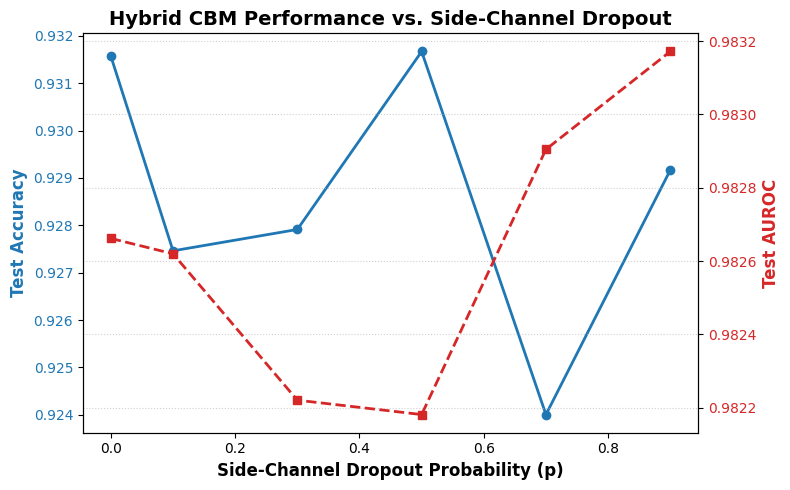

In [ ]:
dropouts = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
m4_accuracies = []
m4_aurocs = []
m4_macro_f1s = []

print("Evaluating Hybrid Models (M4) across Dropouts...\n")

for p in dropouts:
    print(f"Loading and evaluating M4 with dropout p={p}...")

    # 1. Instantiate the model
    m4 = Hybrid(dropout_p=p).to(device)

    # 2. Load the weights from Drive
    filename = f"M4_Hybrid_Dropout_{str(p).replace('.', '')}.pth"
    m4_path = f"{save_dir}/{filename}"
    m4.load_state_dict(torch.load(m4_path, map_location=device))

    # 3. Evaluate target metrics (Accuracy & AUROC)
    acc, auroc = eval_y(m4, test_loader, mode='joint')

    # 4. Evaluate concept metrics (Macro-F1)
    _, macro_f1 = eval_concepts(m4, test_loader, mode='joint')

    m4_accuracies.append(acc)
    m4_aurocs.append(auroc)
    m4_macro_f1s.append(macro_f1)


# REPORT TABLE
print("\n" + "="*65)
print("M4 HYBRID CBM - DROPOUT SWEEP REPORT")
print("="*65)
print(f"{'Dropout (p)':<15} | {'Accuracy':<12} | {'AUROC':<12} | {'Concept Macro-F1':<20}")
print("-" * 65)
for i, p in enumerate(dropouts):
    print(f"{p:<15} | {m4_accuracies[i]:.4f}       | {m4_aurocs[i]:.4f}      | {m4_macro_f1s[i]:.4f}")
print("="*65 + "\n")

# PLOT
fig, ax1 = plt.subplots(figsize=(8, 5))

# Left Y-axis: Test Accuracy
color1 = 'tab:blue'
ax1.set_xlabel('Side-Channel Dropout Probability (p)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy', color=color1, fontsize=12, fontweight='bold')
ax1.plot(dropouts, m4_accuracies, marker='o', color=color1, linewidth=2, label='Target Accuracy')
ax1.tick_params(axis='y', labelcolor=color1)

# Right Y-axis: Test AUROC
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Test AUROC', color=color2, fontsize=12, fontweight='bold')
ax2.plot(dropouts, m4_aurocs, marker='s', color=color2, linewidth=2, linestyle='--', label='Target AUROC')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Hybrid CBM Performance vs. Side-Channel Dropout', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## **Intervention Experiments and Steerability Analysis**
In this phase, we evaluate the "steerability" of our model. The goal is to determine if the model's final decision can be controlled by human intervention at the concept bottleneck level.
Using the Hybrid CBM with high dropout ($p=0.9$), we iterate through the test set and perform interventions by hand. For each image, we flip the predicted value of one of the concepts while keeping the others and the side-channel constant. By measuring how much the final probability of "Smiling" changes and how often the final predicted label flips, we can rank the 10 concepts by their impact on the model's output.

In [ ]:
def evaluate_steerability(model, dataloader, concept_names):
    model.eval()

    # We need to track two things for each concept to measure its true importance:
    # 1. How much the final probability of 'Smiling' shifts when we change it.
    # 2. How many times this change is strong enough to completely flip the final decision (0 to 1, or 1 to 0).
    impact_probs = {name: [] for name in concept_names}
    label_flips = {name: 0 for name in concept_names}
    total_samples = 0

    print("Running Concept Interventions on Test Set...\n")

    with torch.no_grad():
        # For this intervention test, we only care about the images to push them through the network.
        for images, _, _ in dataloader:
            images = images.to(device)
            batch_size = images.size(0)
            total_samples += batch_size

            # STEP 1: Get the baseline prediction
            # First, we extract the base features from the ResNet backbone
            features = model.backbone(images)

            # Now we get what the model originally thinks about the 10 concepts
            c_logits = model.fc_c(features)
            c_probs = torch.sigmoid(c_logits)

            # Calculate the final prediction combining both pathways:
            # the interpretable concept bottleneck and the direct side-channel
            y_c = model.fc_c_to_y(c_probs)
            y_direct = model.fc_direct(features)

            orig_y_total = y_c + y_direct
            orig_probs = torch.sigmoid(orig_y_total)
            orig_preds = (orig_probs >= 0.5).float() # Binary decision

            # STEP 2: The Intervention (Flipping concepts)
            # For every single concept, we will manually change its value and see how the model reacts
            for i, concept in enumerate(concept_names):

                # Make a copy of the original concept probabilities
                intervened_probs = c_probs.clone()

                # If the network predicted < 0.5 (meaning 0), 1.0 - round(prob) becomes 1.0.
                # If it predicted >= 0.5 (meaning 1), it becomes 0.0.
                intervened_probs[:, i] = 1.0 - torch.round(c_probs[:, i])

                # Now we push the altered concepts through the final layer.
                # The side-channel shouldn't be affected by our manual intervention.
                new_y_c = model.fc_c_to_y(intervened_probs)
                new_y_total = new_y_c + y_direct
                new_probs = torch.sigmoid(new_y_total)
                new_preds = (new_probs >= 0.5).float()

                # STEP 3: Measure the impact of our intervention
                # How much did the probability of "Smiling" move?
                prob_diff = torch.abs(new_probs - orig_probs)
                impact_probs[concept].extend(prob_diff.cpu().numpy().flatten().tolist())

                # Did the final prediction change completely?
                flips = torch.sum(new_preds != orig_preds).item()
                label_flips[concept] += flips

    # STEP 4: Put everything together and rank
    ranking_data = []
    for concept in concept_names:
        # Average probability shift across all 19,900 images in the test set
        avg_prob_change = sum(impact_probs[concept]) / len(impact_probs[concept])
        # Percentage of times our manual intervention caused a complete label flip
        flip_rate = (label_flips[concept] / total_samples) * 100

        ranking_data.append((concept, avg_prob_change, flip_rate))

    # Sort the concepts
    ranking_data.sort(key=lambda x: x[1], reverse=True)
    return ranking_data

# EXECUTION BLOCK
# We load the Hybrid model with the highest dropout (p=0.9).
# This specific variant relies the most on the concept bottleneck,
# meaning our manual interventions will have the strongest measurable effect.
m4_09 = Hybrid(dropout_p=0.9).to(device)
m4_09_path = f"{save_dir}/M4_Hybrid_Dropout_09.pth"
m4_09.load_state_dict(torch.load(m4_09_path, map_location=device))

steerability_ranking = evaluate_steerability(m4_09, test_loader, concept_names)

print("="*65)
print("FINAL STEERABILITY RANKING (M4 - p=0.9)")
print("="*65)
print(f"{'Concept Name':<25} | {'Avg Prob Change':<15} | {'Label Flip Rate (%)':<15}")
print("-" * 65)
for concept, avg_prob, flip_rate in steerability_ranking:
    print(f"{concept:<25} | {avg_prob:<15.4f} | {flip_rate:<15.2f}%")
print("="*65 + "\n")

Running Concept Interventions on Test Set...

FINAL STEERABILITY RANKING (M4 - p=0.9)
Concept Name              | Avg Prob Change | Label Flip Rate (%)
-----------------------------------------------------------------
Bushy_Eyebrows            | 0.0095          | 1.04           %
Narrow_Eyes               | 0.0066          | 0.78           %
Bags_Under_Eyes           | 0.0058          | 0.71           %
Big_Lips                  | 0.0058          | 0.65           %
Mouth_Slightly_Open       | 0.0052          | 0.59           %
High_Cheekbones           | 0.0023          | 0.31           %
Arched_Eyebrows           | 0.0022          | 0.26           %
Chubby                    | 0.0019          | 0.26           %
Big_Nose                  | 0.0012          | 0.15           %
Pointy_Nose               | 0.0011          | 0.15           %

